In [1]:
"""
Created on Tue Jun 30 17:50:40 2026

@author: almi3
"""

'\nCreated on Tue Jun 30 17:50:40 2026\n\n@author: almi3\n'

In [2]:
import requests
import pandas as pd
from dateutil.relativedelta import relativedelta
from datetime import datetime, timedelta
import time
import os
import numpy as np
import holidays
import requests
import time
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from dotenv import load_dotenv
load_dotenv(r"C:\Users\almi3\OneDrive\Documentos\MASTER\.env")

True

In [3]:
# =============================================================
# 0. CONFIGURACIÓN
# =============================================================
BASE_URL = "https://apidatos.ree.es"
GEO_PARAMS = {
    "geo_trunc": "electric_system",
    "geo_limit": "peninsular",
    "geo_ids": "8741"}

In [4]:
# =============================================================
# 0. FUNCIÓN PARA EXTRAER UN WIDGET GENÉRICO
# =============================================================
def extraer_widget(categoria, widget, start_date, end_date, time_trunc="hour"):
    url = f"{BASE_URL}/es/datos/{categoria}/{widget}"
    params = {
        "start_date": start_date,
        "end_date": end_date,
        "time_trunc": time_trunc,
        **GEO_PARAMS}
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"  ❌ Error {response.status_code}: {response.text[:300]}")
        response.raise_for_status()
    return response.json()

In [5]:
# =============================================================
# 0. FUNCIÓN PARA EXTRAER LA DEMANDA (evolucion) Y PARSEAR EL JSON A DATAFRAME
# =============================================================
def extraer_demanda_mes(start_date, end_date):
    data = extraer_widget("demanda", "evolucion", start_date, end_date, time_trunc="hour")
    
    # El widget evolucion devuelve varios indicadores en included[]
    # El que nos interesa es la demanda real (type = "Demanda real")
    registros = []
    for item in data["included"]:
        tipo = item["type"]
        for v in item["attributes"]["values"]:
            registros.append({
                "datetime": v["datetime"],
                "value": v["value"],
                "tipo": tipo})
    return pd.DataFrame(registros)

In [6]:
# =============================================================
# EXTRACCIÓN HISTÓRICA MES A MES
# =============================================================
def extraer_historico(fecha_inicio, fecha_fin):
    dfs = []
    fecha_actual = fecha_inicio

    while fecha_actual < fecha_fin:
        fecha_sig = fecha_actual + relativedelta(months=1)
        start = fecha_actual.strftime("%Y-%m-%dT00:00")
        end   = (fecha_sig - relativedelta(days=1)).strftime("%Y-%m-%dT23:59")

        print(f"📥 Extrayendo {fecha_actual.strftime('%Y-%m')}...")
        try:
            df_mes = extraer_demanda_mes(start, end)
            dfs.append(df_mes)
        except Exception as e:
            print(f"  ⚠️ Saltando {fecha_actual.strftime('%Y-%m')}: {e}")

        fecha_actual = fecha_sig
        time.sleep(0.5)  # pausa para no saturar la API

    if not dfs:
        raise ValueError("No se extrajo ningún dato.")

    df = pd.concat(dfs, ignore_index=True)
    return df

In [7]:
# =============================================================
# MAIN
# =============================================================
if __name__ == "__main__":

    # PASO 1: prueba rápida con una semana antes del histórico completo
    print("=== TEST RÁPIDO ===")
    try:
        df_test = extraer_demanda_mes("2023-01-01T00:00", "2023-01-07T23:59")
        print(df_test.head(10))
        print(f"Tipos de indicadores disponibles: {df_test['tipo'].unique()}")
        print("✅ Conexión OK\n")
    except Exception as e:
        print(f"❌ Falló el test: {e}")

    # PASO 2: extracción completa
    print("=== EXTRACCIÓN COMPLETA ===")
    df = extraer_historico(datetime(2019, 1, 1), datetime(2026, 1, 1))
    # Quedarse solo con la demanda real peninsular
    df_demanda = df[df["tipo"] == "Demanda"].copy()
    df_demanda["datetime"] = pd.to_datetime(df_demanda["datetime"], utc=True)\
                               .dt.tz_convert("Europe/Madrid")
    df_demanda = df_demanda.rename(columns={"value": "demanda_mw"})\
                           .sort_values("datetime")\
                           .reset_index(drop=True)
    print(df_demanda.head())
    print(f"Shape: {df_demanda.shape}")
    print(f"Rango: {df_demanda['datetime'].min()} → {df_demanda['datetime'].max()}")    
    df_demanda.to_parquet("demanda_ree_2019_2025.parquet", index=False)
    df_demanda.to_csv("demanda_ree_2019_2025.csv", index=False)
    print("💾 Datos guardados.")

=== TEST RÁPIDO ===
                        datetime      value     tipo
0  2023-01-01T00:00:00.000+01:00  19872.637  Demanda
1  2023-01-01T01:00:00.000+01:00  19198.718  Demanda
2  2023-01-01T02:00:00.000+01:00  18099.597  Demanda
3  2023-01-01T03:00:00.000+01:00  17142.238  Demanda
4  2023-01-01T04:00:00.000+01:00  16539.586  Demanda
5  2023-01-01T05:00:00.000+01:00  16272.179  Demanda
6  2023-01-01T06:00:00.000+01:00  16324.629  Demanda
7  2023-01-01T07:00:00.000+01:00  16582.757  Demanda
8  2023-01-01T08:00:00.000+01:00  16510.280  Demanda
9  2023-01-01T09:00:00.000+01:00  17068.005  Demanda
Tipos de indicadores disponibles: ['Demanda']
✅ Conexión OK

=== EXTRACCIÓN COMPLETA ===
📥 Extrayendo 2019-01...
📥 Extrayendo 2019-02...
📥 Extrayendo 2019-03...
📥 Extrayendo 2019-04...
📥 Extrayendo 2019-05...
📥 Extrayendo 2019-06...
📥 Extrayendo 2019-07...
📥 Extrayendo 2019-08...
📥 Extrayendo 2019-09...
📥 Extrayendo 2019-10...
📥 Extrayendo 2019-11...
📥 Extrayendo 2019-12...
📥 Extrayendo 2020-01

In [8]:
# =============================================================
# CARGAR DATASET BASE
# =============================================================
df = pd.read_parquet("demanda_ree_2019_2025.parquet")
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Dataset inicial: {df.shape}")
print(df.head())

Dataset inicial: (61368, 3)
                   datetime  demanda_mw     tipo
0 2019-01-01 00:00:00+01:00   23209.473  Demanda
1 2019-01-01 01:00:00+01:00   22406.330  Demanda
2 2019-01-01 02:00:00+01:00   21090.596  Demanda
3 2019-01-01 03:00:00+01:00   19896.113  Demanda
4 2019-01-01 04:00:00+01:00   19146.631  Demanda


In [9]:
# =============================================================
# NIVEL 1: VARIABLES DERIVADAS DEL DATETIME
# =============================================================
print("\n📅 Creando variables de calendario...")

df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek  # 0=lunes, 6=domingo
df["dayofyear"] = df["datetime"].dt.dayofyear
df["quarter"] = df["datetime"].dt.quarter
df["weekofyear"] = df["datetime"].dt.isocalendar().week

# Variables booleanas
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# Estación del año
def asignar_estacion(row):
    month = row["month"]
    if month in [12, 1, 2]:
        return "invierno"
    elif month in [3, 4, 5]:
        return "primavera"
    elif month in [6, 7, 8]:
        return "verano"
    else:
        return "otoño"

df["estacion"] = df.apply(asignar_estacion, axis=1)


# Festivos nacionales españoles
es_holidays = holidays.Spain(years=range(df["datetime"].dt.year.min(), df["datetime"].dt.year.max() + 1))
df["is_festivo_nacional"] = df["datetime"].dt.date.isin(
    es_holidays.keys()).astype(int)
 
# Tipo de día (combinación)
def tipo_dia(row):
    if row["is_festivo_nacional"] == 1:
        return "festivo"
    elif row["is_weekend"] == 1:
        return "fin_semana"
    else:
        return "laborable"
 
df["tipo_dia"] = df.apply(tipo_dia, axis=1)


📅 Creando variables de calendario...


In [10]:
print("✅ Variables de calendario creadas")
print(df[["datetime", "hour", "dayofweek", "is_weekend", "estacion", "is_festivo_nacional", "tipo_dia"]].head(10))

✅ Variables de calendario creadas
                   datetime  hour  dayofweek  is_weekend  estacion  \
0 2019-01-01 00:00:00+01:00     0          1           0  invierno   
1 2019-01-01 01:00:00+01:00     1          1           0  invierno   
2 2019-01-01 02:00:00+01:00     2          1           0  invierno   
3 2019-01-01 03:00:00+01:00     3          1           0  invierno   
4 2019-01-01 04:00:00+01:00     4          1           0  invierno   
5 2019-01-01 05:00:00+01:00     5          1           0  invierno   
6 2019-01-01 06:00:00+01:00     6          1           0  invierno   
7 2019-01-01 07:00:00+01:00     7          1           0  invierno   
8 2019-01-01 08:00:00+01:00     8          1           0  invierno   
9 2019-01-01 09:00:00+01:00     9          1           0  invierno   

   is_festivo_nacional tipo_dia  
0                    1  festivo  
1                    1  festivo  
2                    1  festivo  
3                    1  festivo  
4                    1  f

In [11]:
# =============================================================
# VARIABLES LAG Y MEDIAS MÓVILES
# =============================================================
print("\n📊 Creando lags y medias móviles...")

df["lag_24h"] = df["demanda_mw"].shift(24)
df["lag_48h"] = df["demanda_mw"].shift(48)
df["lag_168h"] = df["demanda_mw"].shift(168)  # una semana

df["ma_24h"] = (df["demanda_mw"].shift(1).rolling(window=24).mean())

df["ma_168h"] = (df["demanda_mw"].shift(1).rolling(window=168).mean())


📊 Creando lags y medias móviles...


In [12]:
print("✅ Lags y medias móviles creadas")
print(df[["demanda_mw", "lag_24h", "lag_168h", "ma_24h"]].head(30))

✅ Lags y medias móviles creadas
    demanda_mw    lag_24h  lag_168h        ma_24h
0    23209.473        NaN       NaN           NaN
1    22406.330        NaN       NaN           NaN
2    21090.596        NaN       NaN           NaN
3    19896.113        NaN       NaN           NaN
4    19146.631        NaN       NaN           NaN
5    18879.367        NaN       NaN           NaN
6    19048.697        NaN       NaN           NaN
7    19485.333        NaN       NaN           NaN
8    19396.660        NaN       NaN           NaN
9    20068.625        NaN       NaN           NaN
10   21716.741        NaN       NaN           NaN
11   22990.667        NaN       NaN           NaN
12   23541.830        NaN       NaN           NaN
13   24061.123        NaN       NaN           NaN
14   23965.991        NaN       NaN           NaN
15   22711.148        NaN       NaN           NaN
16   22233.075        NaN       NaN           NaN
17   22671.041        NaN       NaN           NaN
18   25315.672    

In [13]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dayofweek_sin"] = np.sin(
    2 * np.pi * df["dayofweek"] / 7)

df["dayofweek_cos"] = np.cos(
    2 * np.pi * df["dayofweek"] / 7)

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12)

In [14]:
# =============================================================
# NIVEL 2: TEMPERATURA DE AEMET
# =============================================================

AEMET_API_KEY = os.environ.get("AEMET_API_KEY")

if not AEMET_API_KEY:
    raise ValueError(
        "No se ha encontrado la variable de entorno AEMET_API_KEY.")


def extraer_climatologia_aemet(estacion_id, fecha_inicio, fecha_fin):
    """
    Extrae datos climatológicos diarios de AEMET
    para una estación y rango de fechas.
    """

    url = ("https://opendata.aemet.es/opendata/api/"
        "valores/climatologicos/diarios/datos/"
        f"fechaini/{fecha_inicio}/"
        f"fechafin/{fecha_fin}/"
        f"estacion/{estacion_id}")

    headers = {"api_key": AEMET_API_KEY}

    response = requests.get(url, headers=headers, timeout=30)

    if response.status_code != 200:
        raise RuntimeError(
            f"Error AEMET {response.status_code}: "
            f"{response.text[:500]}")

    respuesta = response.json()

    if "datos" not in respuesta:
        raise RuntimeError(
            f"AEMET no devolvió una URL de datos: {respuesta}")

    datos_url = respuesta["datos"]

    response_datos = requests.get(
        datos_url,
        timeout=30)

    if response_datos.status_code != 200:
        raise RuntimeError(
            f"Error descargando datos AEMET: "
            f"{response_datos.status_code}")

    datos = response_datos.json()

    return pd.DataFrame(datos)


def extraer_climatologia_historico(estacion_id, fecha_inicio, fecha_fin, meses_por_bloque=5):
    """
    AEMET limita el rango de fechas por llamada, así que troceamos
    la extracción en bloques (por defecto 5 meses) y respetamos
    el rate limit de la API con una pausa entre peticiones.
    """
    dfs = []
    actual = fecha_inicio
    while actual < fecha_fin:
        siguiente = min(actual + relativedelta(months=meses_por_bloque), fecha_fin)
        ini_str = actual.strftime("%Y-%m-%dT00:00:00UTC")
        fin_str = siguiente.strftime("%Y-%m-%dT23:59:59UTC")
        print(f"📥 AEMET {actual.strftime('%Y-%m')} → {siguiente.strftime('%Y-%m')}...")
        try:
            df_bloque = extraer_climatologia_aemet(estacion_id, ini_str, fin_str)
            if not df_bloque.empty:
                dfs.append(df_bloque)
        except Exception as e:
            print(f"  ⚠️ Saltando bloque: {e}")
        actual = siguiente
        time.sleep(1.5)  # AEMET es estricto con el rate limit
    if not dfs:
        raise ValueError("No se extrajo ningún dato climatológico.")
    return pd.concat(dfs, ignore_index=True)

def procesar_climatologia(df_clima):
    """
    Limpia el dataframe crudo de AEMET: convierte comas decimales a
    float y nos quedamos con temperatura media/máx/mín diaria.
    """
    df = df_clima.copy()
    df["fecha"] = pd.to_datetime(df["fecha"])
    for col in ["tmed", "tmax", "tmin"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(",", ".", regex=False).astype(float)
    return df[["fecha", "tmed", "tmax", "tmin"]].rename(
        columns={"tmed": "temp_media_c", "tmax": "temp_max_c", "tmin": "temp_min_c"})

In [15]:
# --- 1. Obtener el inventario completo de estaciones de AEMET ---
def obtener_inventario_estaciones():
    url = "https://opendata.aemet.es/opendata/api/valores/climatologicos/inventarioestaciones/todasestaciones"
    headers = {"api_key": AEMET_API_KEY}
    response = requests.get(url, headers=headers, timeout=30)
    if response.status_code != 200:
        raise RuntimeError(f"Error AEMET {response.status_code}: {response.text[:300]}")
    datos_url = response.json()["datos"]
    response_datos = requests.get(datos_url, timeout=30)
    inventario = pd.DataFrame(response_datos.json())
    # latitud/longitud vienen en formato AEMET (grados-minutos-segundos + N/S/E/W)
    return inventario

In [16]:
inventario = obtener_inventario_estaciones()
print(f"Inventario AEMET: {inventario.shape[0]} estaciones totales")

Inventario AEMET: 926 estaciones totales


In [17]:
# --- 2. Localizar la estación principal de cada ciudad objetivo ---
# Ciudades peninsulares, distribuidas geográficamente, con peso por población de provincia

CIUDADES_OBJETIVO = {
    "MADRID":       {"busca": "MADRID",     "provincia": "MADRID",     "poblacion": 6800},
    "BARCELONA":    {"busca": "BARCELONA",  "provincia": "BARCELONA",  "poblacion": 5700},
    "VALENCIA":     {"busca": "VALENCIA",   "provincia": "VALENCIA",   "poblacion": 2600},
    "SEVILLA":      {"busca": "SEVILLA",    "provincia": "SEVILLA",    "poblacion": 1950},
    "BILBAO":       {"busca": "BILBAO",     "provincia": None,         "poblacion": 1150},
    "ZARAGOZA":     {"busca": "ZARAGOZA",   "provincia": "ZARAGOZA",   "poblacion": 970},
    "MALAGA":       {"busca": "MALAGA",     "provincia": "MALAGA",     "poblacion": 1730},
    "A_CORUNA":     {"busca": "CORUÑA",     "provincia": "CORUÑA",     "poblacion": 1120},
    "MURCIA":       {"busca": "MURCIA",     "provincia": "MURCIA",     "poblacion": 1590},
    "ALICANTE":     {"busca": "ALICANTE",   "provincia": "ALICANTE",   "poblacion": 1900},
    "VALLADOLID":   {"busca": "VALLADOLID", "provincia": "VALLADOLID", "poblacion": 520}}
    
# Nota: BILBAO no filtra por provincia porque AEMET la clasifica bajo
# "VIZCAYA" o "BIZKAIA" según la fuente, y no queremos que un fallo de
# ortografía descarte la única coincidencia válida.

estaciones_seleccionadas = {}

for ciudad, info in CIUDADES_OBJETIVO.items():
    candidatas = inventario[
        inventario["nombre"].str.contains(info["busca"], case=False, na=False)]

    # Filtro de provincia, si se ha especificado uno
    if info["provincia"] is not None:
        candidatas_provincia = candidatas[
            candidatas["provincia"].str.contains(info["provincia"], case=False, na=False)
        ]
        if not candidatas_provincia.empty:
            candidatas = candidatas_provincia

    if candidatas.empty:
        print(f"  ⚠️ Sin coincidencias para {ciudad} (\"{info['busca']}\") — revisa el nombre/provincia")
        continue

    # Preferencia automática por AEROPUERTO
    candidatas_aeropuerto = candidatas[candidatas["nombre"].str.contains("AEROPUERTO", case=False, na=False)]
    seleccionada = candidatas_aeropuerto.iloc[0] if not candidatas_aeropuerto.empty else candidatas.iloc[0]

    print(f"\n{ciudad}: {len(candidatas)} candidatas tras filtro de provincia")
    print(candidatas[["indicativo", "nombre", "provincia"]].to_string(index=False))
    print(f"  → Seleccionada: {seleccionada['indicativo']} ({seleccionada['nombre']})"
          f"{' [AEROPUERTO, preferida automáticamente]' if not candidatas_aeropuerto.empty else ' [sin aeropuerto disponible, primera candidata]'}")

    estaciones_seleccionadas[ciudad] = {
        "indicativo": seleccionada["indicativo"],
        "nombre": seleccionada["nombre"],
        "poblacion": info["poblacion"]}


MADRID: 5 candidatas tras filtro de provincia
indicativo                       nombre provincia
     3126Y            MADRID, EL GOLOSO    MADRID
      3129            MADRID AEROPUERTO    MADRID
     3194U MADRID, CIUDAD UNIVERSITARIA    MADRID
      3195               MADRID, RETIRO    MADRID
      3196       MADRID, CUATRO VIENTOS    MADRID
  → Seleccionada: 3129 (MADRID AEROPUERTO) [AEROPUERTO, preferida automáticamente]

BARCELONA: 4 candidatas tras filtro de provincia
indicativo                  nombre provincia
      0076    BARCELONA AEROPUERTO BARCELONA
     0200E        BARCELONA, FABRA BARCELONA
     0201D BARCELONA, PORT OLÍMPIC BARCELONA
     0201X    BARCELONA, DRASSANES BARCELONA
  → Seleccionada: 0076 (BARCELONA AEROPUERTO) [AEROPUERTO, preferida automáticamente]

VALENCIA: 2 candidatas tras filtro de provincia
indicativo              nombre provincia
     8414A VALENCIA AEROPUERTO  VALENCIA
     8416X       VALENCIA, UPV  VALENCIA
  → Seleccionada: 8414A (VALENCIA AER

In [18]:
print("\n" + "=" * 70)
print("ESTACIONES SELECCIONADAS:")
for ciudad, info in estaciones_seleccionadas.items():
    print(f"  {ciudad:12s} → {info['indicativo']} ({info['nombre']}) — peso: {info['poblacion']}")
print("=" * 70)


ESTACIONES SELECCIONADAS:
  MADRID       → 3129 (MADRID AEROPUERTO) — peso: 6800
  BARCELONA    → 0076 (BARCELONA AEROPUERTO) — peso: 5700
  VALENCIA     → 8414A (VALENCIA AEROPUERTO) — peso: 2600
  SEVILLA      → 5783 (SEVILLA AEROPUERTO) — peso: 1950
  BILBAO       → 1082 (BILBAO AEROPUERTO) — peso: 1150
  ZARAGOZA     → 9434 (ZARAGOZA, AEROPUERTO) — peso: 970
  A_CORUNA     → 1387E (A CORUÑA AEROPUERTO) — peso: 1120
  MURCIA       → 7020C (MURCIA AEROPUERTO) — peso: 1590
  ALICANTE     → 8019 (ALICANTE-ELCHE AEROPUERTO) — peso: 1900
  VALLADOLID   → 2539 (VALLADOLID AEROPUERTO) — peso: 520


In [19]:
# --- 3. Extraer histórico de cada estación seleccionada ---
dfs_por_ciudad = {}
for ciudad, info in estaciones_seleccionadas.items():
    print(f"\n📥 Extrayendo temperatura histórica: {ciudad} ({info['indicativo']})...")
    try:
        df_raw = extraer_climatologia_historico(
            info["indicativo"], datetime(2019, 1, 1), datetime(2026, 1, 1))
        df_ciudad = procesar_climatologia(df_raw)
        df_ciudad["ciudad"] = ciudad
        dfs_por_ciudad[ciudad] = df_ciudad
        print(f"  ✅ {ciudad}: {df_ciudad.shape[0]} días")
    except Exception as e:
        print(f"  ⚠️ Fallo en {ciudad}: {e}")
    time.sleep(1)


📥 Extrayendo temperatura histórica: MADRID (3129)...
📥 AEMET 2019-01 → 2019-06...
📥 AEMET 2019-06 → 2019-11...
📥 AEMET 2019-11 → 2020-04...
📥 AEMET 2020-04 → 2020-09...
📥 AEMET 2020-09 → 2021-02...
📥 AEMET 2021-02 → 2021-07...
📥 AEMET 2021-07 → 2021-12...
📥 AEMET 2021-12 → 2022-05...
📥 AEMET 2022-05 → 2022-10...
📥 AEMET 2022-10 → 2023-03...
📥 AEMET 2023-03 → 2023-08...
📥 AEMET 2023-08 → 2024-01...
📥 AEMET 2024-01 → 2024-06...
📥 AEMET 2024-06 → 2024-11...
📥 AEMET 2024-11 → 2025-04...
📥 AEMET 2025-04 → 2025-09...
📥 AEMET 2025-09 → 2026-01...
  ✅ MADRID: 2574 días

📥 Extrayendo temperatura histórica: BARCELONA (0076)...
📥 AEMET 2019-01 → 2019-06...
📥 AEMET 2019-06 → 2019-11...
📥 AEMET 2019-11 → 2020-04...
📥 AEMET 2020-04 → 2020-09...
📥 AEMET 2020-09 → 2021-02...
📥 AEMET 2021-02 → 2021-07...
📥 AEMET 2021-07 → 2021-12...
📥 AEMET 2021-12 → 2022-05...
📥 AEMET 2022-05 → 2022-10...
📥 AEMET 2022-10 → 2023-03...
📥 AEMET 2023-03 → 2023-08...
📥 AEMET 2023-08 → 2024-01...
📥 AEMET 2024-01 → 2024-06.

In [20]:
# --- 4. Guardar temperatura por ciudad para el mapa de Streamlit ---
df_temp_ciudades = pd.concat(dfs_por_ciudad.values(), ignore_index=True)
df_temp_ciudades.to_csv("temperatura_por_ciudad.csv", index=False)
print(f"\n💾 Temperatura por ciudad guardada: {df_temp_ciudades.shape}")


💾 Temperatura por ciudad guardada: (25740, 5)


In [21]:
# Coordenadas de cada ciudad, para el mapa (lat/lon aproximados del centro urbano)
COORDENADAS_CIUDADES = {
    "MADRID":     (40.4168, -3.7038),
    "BARCELONA":  (41.3851, 2.1734),
    "VALENCIA":   (39.4699, -0.3763),
    "SEVILLA":    (37.3891, -5.9845),
    "BILBAO":     (43.2630, -2.9350),
    "ZARAGOZA":   (41.6488, -0.8891),
    "MALAGA":     (36.7213, -4.4214),
    "A_CORUNA":   (43.3623, -8.4115),
    "MURCIA":     (37.9922, -1.1307),
    "ALICANTE":   (38.3452, -0.4810),
    "OVIEDO":     (43.3619, -5.8494),
    "VALLADOLID": (41.6523, -4.7245)}

df_coordenadas = pd.DataFrame([
    {"ciudad": c, "lat": lat, "lon": lon, "poblacion": estaciones_seleccionadas[c]["poblacion"]}
    for c, (lat, lon) in COORDENADAS_CIUDADES.items() if c in estaciones_seleccionadas])
df_coordenadas.to_csv("coordenadas_ciudades.csv", index=False)

In [22]:
# --- 5. Calcular temperatura nacional ponderada por población ---
peso_total = sum(info["poblacion"] for info in estaciones_seleccionadas.values())
for ciudad in df_temp_ciudades["ciudad"].unique():
    df_temp_ciudades.loc[df_temp_ciudades["ciudad"] == ciudad, "peso"] = (
        estaciones_seleccionadas[ciudad]["poblacion"] / peso_total)
df_temp_ciudades["temp_ponderada"] = df_temp_ciudades["temp_media_c"] * df_temp_ciudades["peso"]

temperatura_nacional = (
    df_temp_ciudades.groupby("fecha")["temp_ponderada"].sum().reset_index()
    .rename(columns={"temp_ponderada": "temperatura_c"}))

temperatura_nacional.to_csv("temperatura_nacional_ponderada.csv", index=False)
print(f"\n💾 Temperatura nacional ponderada guardada: {temperatura_nacional.shape}")


💾 Temperatura nacional ponderada guardada: (2558, 2)


In [23]:
# --- 6. Fusionar con el dataset de demanda ---
df["fecha"] = df["datetime"].dt.date
temperatura_nacional["fecha"] = pd.to_datetime(temperatura_nacional["fecha"]).dt.date
df = df.drop(columns=["temperatura_c"], errors="ignore")  # por si ya existía de la versión de una estación
df = df.merge(temperatura_nacional, on="fecha", how="left")
df["temperatura_c"] = df["temperatura_c"].interpolate(limit=48, limit_direction="both")

In [24]:
print(f"\n✅ Dataset actualizado con temperatura nacional ponderada: {df.shape}")
print(df[["datetime", "temperatura_c"]].head())


✅ Dataset actualizado con temperatura nacional ponderada: (61368, 28)
                   datetime  temperatura_c
0 2019-01-01 00:00:00+01:00       8.513745
1 2019-01-01 01:00:00+01:00       8.513745
2 2019-01-01 02:00:00+01:00       8.513745
3 2019-01-01 03:00:00+01:00       8.513745
4 2019-01-01 04:00:00+01:00       8.513745


In [25]:
# =============================================================
# LIMPIEZA DE NULOS (por los lags)
# =============================================================
print("\n Limpiando datos...")

# Los primeros 168 registros tendrán NaN en lag_168h
df_limpio = df.dropna(subset=["lag_24h", "lag_168h", "temperatura_c"]).copy()

print(f"Filas originales: {len(df)}")
print(f"Filas después de limpiar NaN de lags: {len(df_limpio)}")
print(f"Registros eliminados: {len(df) - len(df_limpio)}")


 Limpiando datos...
Filas originales: 61368
Filas después de limpiar NaN de lags: 61200
Registros eliminados: 168


In [26]:
# =============================================================
# GUARDAR DATASET ENRIQUECIDO
# =============================================================
print("\n💾 Guardando dataset enriquecido...")

df_limpio.to_parquet("demanda_ree_enriquecido_2019_2025.parquet", index=False)
df_limpio.to_csv("demanda_ree_enriquecido_2019_2025.csv", index=False)

print(f"\nDataset final: {df_limpio.shape}")
print(f"\nColumnas disponibles:")
print(df_limpio.columns.tolist())
print("\n" + "="*60)
print(df_limpio.head())
print("\n" + "="*60)
print(df_limpio.describe())


💾 Guardando dataset enriquecido...

Dataset final: (61200, 28)

Columnas disponibles:
['datetime', 'demanda_mw', 'tipo', 'year', 'month', 'day', 'hour', 'dayofweek', 'dayofyear', 'quarter', 'weekofyear', 'is_weekend', 'estacion', 'is_festivo_nacional', 'tipo_dia', 'lag_24h', 'lag_48h', 'lag_168h', 'ma_24h', 'ma_168h', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'fecha', 'temperatura_c']

                     datetime  demanda_mw     tipo  year  month  day  hour  \
168 2019-01-08 00:00:00+01:00   28079.838  Demanda  2019      1    8     0   
169 2019-01-08 01:00:00+01:00   25849.914  Demanda  2019      1    8     1   
170 2019-01-08 02:00:00+01:00   24715.502  Demanda  2019      1    8     2   
171 2019-01-08 03:00:00+01:00   24149.657  Demanda  2019      1    8     3   
172 2019-01-08 04:00:00+01:00   24192.680  Demanda  2019      1    8     4   

     dayofweek  dayofyear  quarter  ...        ma_24h       ma_168h  hour_sin  \
168          1    

In [27]:
# =============================================================
# CARGAR DATASET ENRIQUECIDO
# =============================================================
df = pd.read_parquet("demanda_ree_enriquecido_2019_2025.parquet")

print("="*70)
print("ANÁLISIS EXPLORATORIO Y DESCRIPTIVO (EDA)")
print("="*70)

ANÁLISIS EXPLORATORIO Y DESCRIPTIVO (EDA)



4.1 EVOLUCIÓN HISTÓRICA
----------------------------------------------------------------------


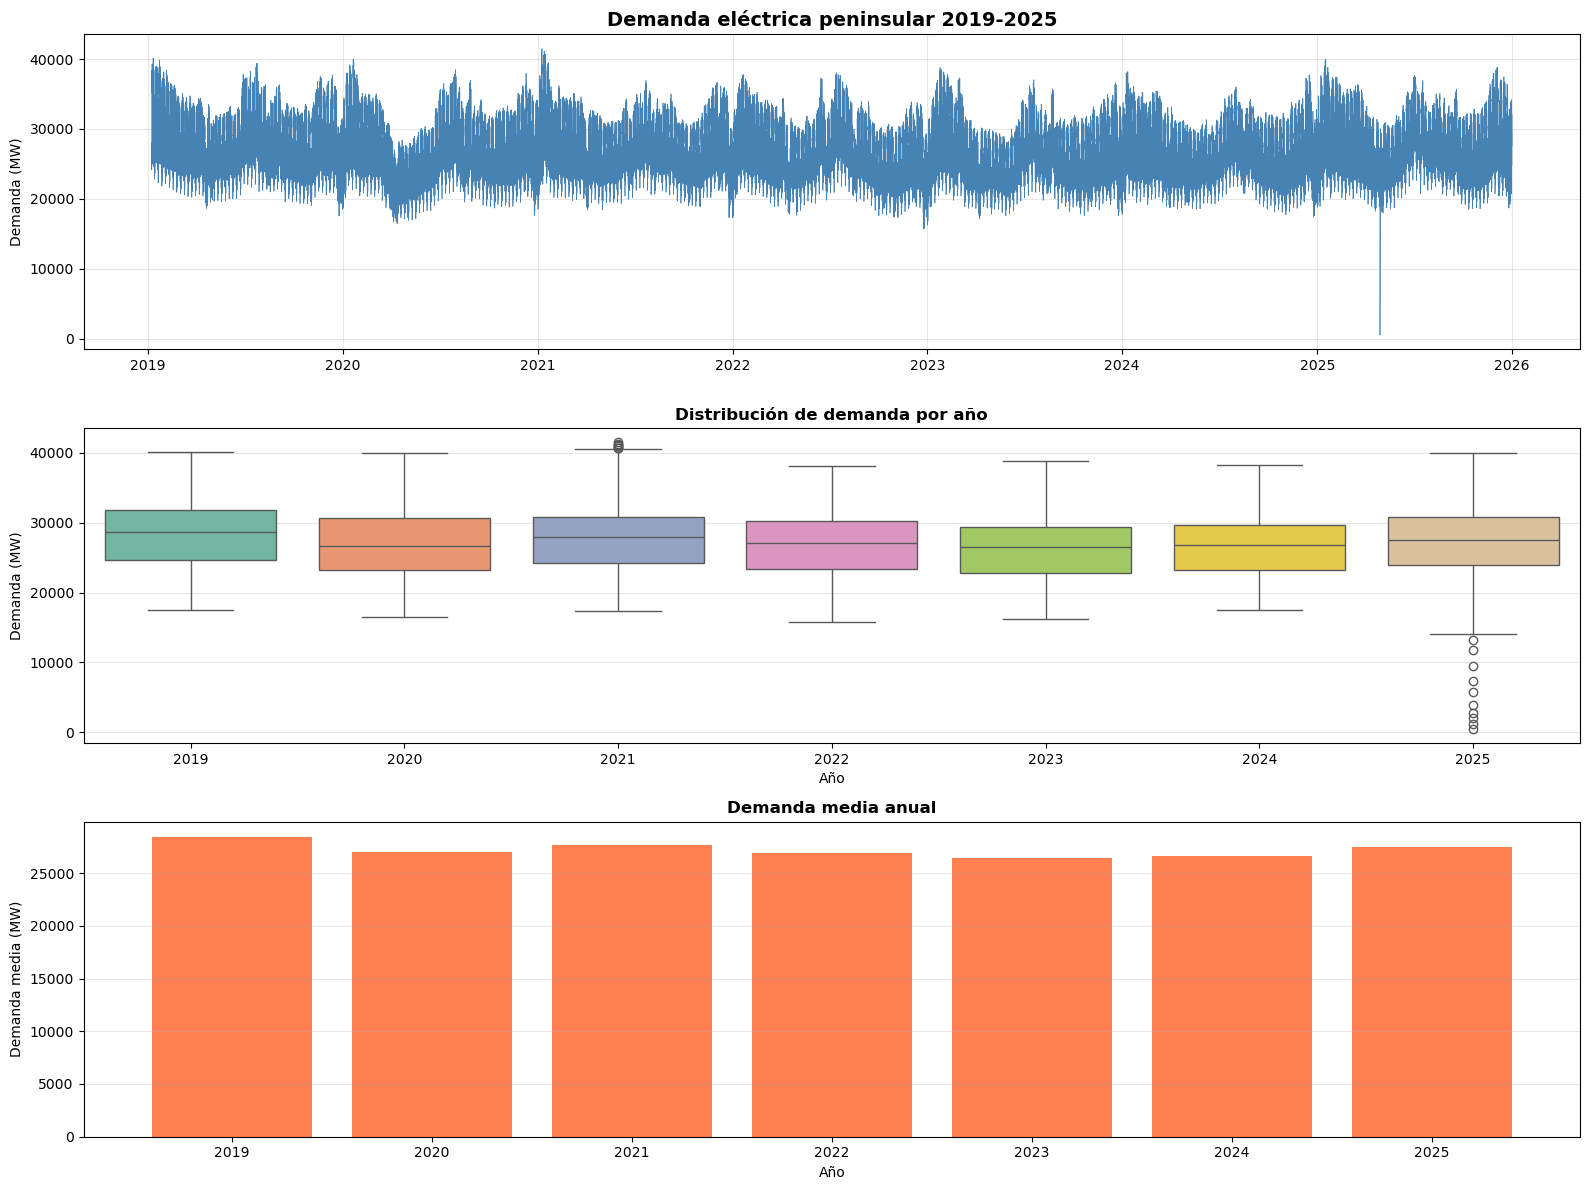

✅ Gráfico guardado: 01_evolucion_historica.png


In [28]:
# =============================================================
# 4.1 EVOLUCIÓN HISTÓRICA DE LA DEMANDA
# =============================================================
print("\n4.1 EVOLUCIÓN HISTÓRICA")
print("-" * 70)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Gráfico 1: Serie temporal completa
axes[0].plot(df["datetime"], df["demanda_mw"], linewidth=0.5, color="steelblue")
axes[0].set_title("Demanda eléctrica peninsular 2019-2025", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Demanda (MW)")
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Por año (boxplot)
df["year_str"] = df["year"].astype(str)
sns.boxplot(data=df, x="year_str", y="demanda_mw", ax=axes[1], hue="year_str", palette="Set2", legend=False)
axes[1].set_title("Distribución de demanda por año", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Demanda (MW)")
axes[1].set_xlabel("Año")
axes[1].grid(True, alpha=0.3, axis="y")

# Gráfico 3: Promedio diario por año
demanda_diaria = df.groupby(df["datetime"].dt.date)["demanda_mw"].mean()
# Convertir a datetime
demanda_diaria.index = pd.to_datetime(demanda_diaria.index)
demanda_por_ano = demanda_diaria.groupby(demanda_diaria.index.year).mean()
axes[2].bar(demanda_por_ano.index.astype(str), demanda_por_ano.values, color="coral")
axes[2].set_title("Demanda media anual", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Demanda media (MW)")
axes[2].set_xlabel("Año")
axes[2].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("01_evolucion_historica.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfico guardado: 01_evolucion_historica.png")


4.2 PATRONES TEMPORALES
----------------------------------------------------------------------


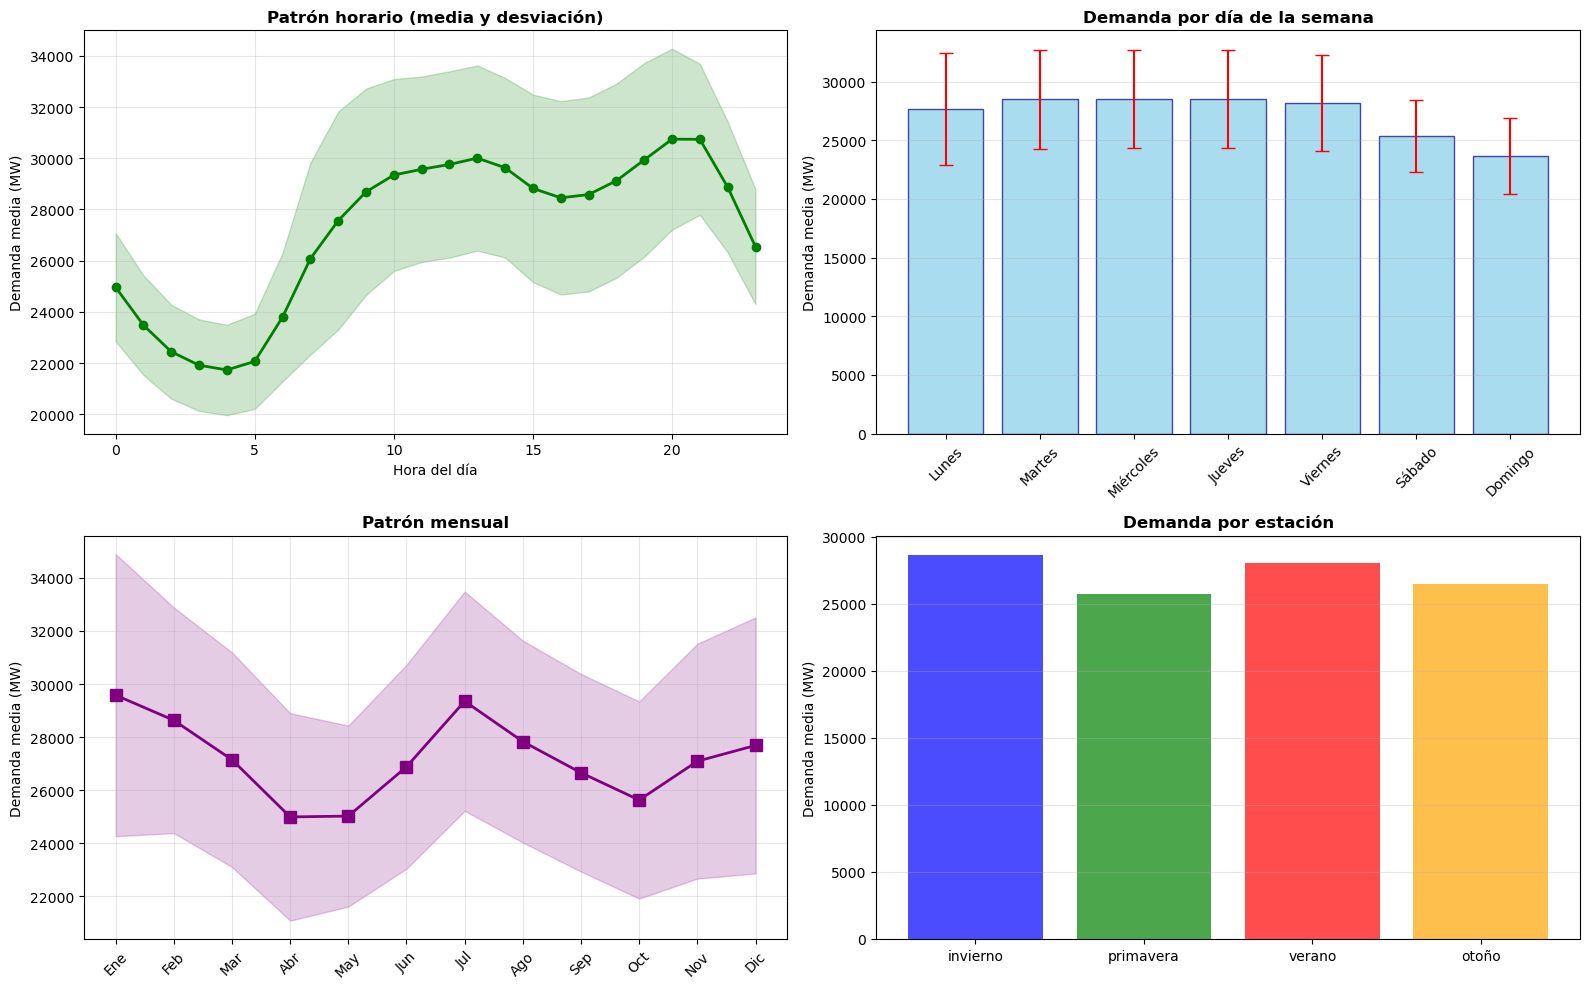

✅ Gráfico guardado: 02_patrones_temporales.png


In [29]:
# =============================================================
# 4.2 PATRONES POR HORA, DÍA DE SEMANA Y MES
# =============================================================
print("\n4.2 PATRONES TEMPORALES")
print("-" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Por hora del día
demanda_por_hora = df.groupby("hour")["demanda_mw"].agg(["mean", "std"])
axes[0, 0].plot(demanda_por_hora.index, demanda_por_hora["mean"], marker="o", color="green", linewidth=2)
axes[0, 0].fill_between(demanda_por_hora.index, 
                        demanda_por_hora["mean"] - demanda_por_hora["std"],
                        demanda_por_hora["mean"] + demanda_por_hora["std"],
                        alpha=0.2, color="green")
axes[0, 0].set_title("Patrón horario (media y desviación)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Hora del día")
axes[0, 0].set_ylabel("Demanda media (MW)")
axes[0, 0].grid(True, alpha=0.3)

# Por día de la semana
dias = {0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves", 4: "Viernes", 5: "Sábado", 6: "Domingo"}
demanda_por_dia = df.groupby("dayofweek")["demanda_mw"].agg(["mean", "std"])
axes[0, 1].bar(range(7), demanda_por_dia["mean"], color="skyblue", alpha=0.7, edgecolor="navy")
axes[0, 1].errorbar(range(7), demanda_por_dia["mean"], yerr=demanda_por_dia["std"], 
                     fmt="none", ecolor="red", capsize=5)
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels([dias[i] for i in range(7)], rotation=45)
axes[0, 1].set_title("Demanda por día de la semana", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Demanda media (MW)")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Por mes
demanda_por_mes = df.groupby("month")["demanda_mw"].agg(["mean", "std"])
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
axes[1, 0].plot(range(1, 13), demanda_por_mes["mean"], marker="s", color="purple", linewidth=2, markersize=8)
axes[1, 0].fill_between(range(1, 13),
                        demanda_por_mes["mean"] - demanda_por_mes["std"],
                        demanda_por_mes["mean"] + demanda_por_mes["std"],
                        alpha=0.2, color="purple")
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(meses, rotation=45)
axes[1, 0].set_title("Patrón mensual", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Demanda media (MW)")
axes[1, 0].grid(True, alpha=0.3)

# Por estación
demanda_por_estacion = df.groupby("estacion")["demanda_mw"].agg(["mean", "std"])
estaciones_order = ["invierno", "primavera", "verano", "otoño"]
demanda_por_estacion = demanda_por_estacion.reindex(estaciones_order)
axes[1, 1].bar(estaciones_order, demanda_por_estacion["mean"], color=["blue", "green", "red", "orange"], alpha=0.7)
axes[1, 1].set_title("Demanda por estación", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Demanda media (MW)")
axes[1, 1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("02_patrones_temporales.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfico guardado: 02_patrones_temporales.png")


4.3 IMPACTO DEL TIPO DE DÍA
----------------------------------------------------------------------
                    mean          std  count
tipo_dia                                    
festivo     23372.861252  3189.001931   1416
fin_semana  24527.247911  3265.862329  17256
laborable   28415.722927  4265.012186  42528


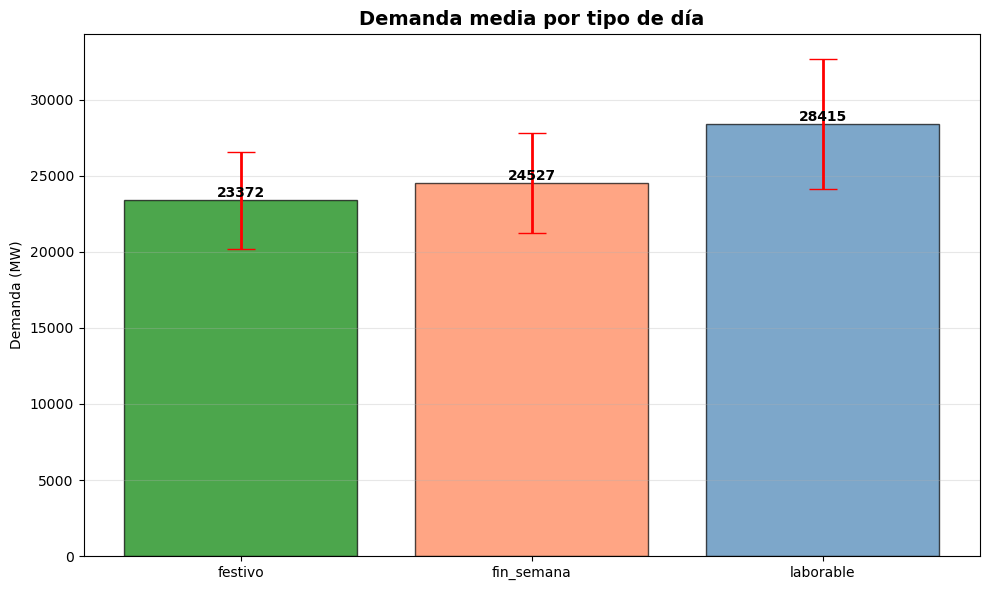

✅ Gráfico guardado: 03_tipo_dia.png


In [30]:
# =============================================================
# 4.3 TIPO DE DÍA (LABORABLE, FIN DE SEMANA, FESTIVO)
# =============================================================
print("\n4.3 IMPACTO DEL TIPO DE DÍA")
print("-" * 70)

demanda_por_tipo_dia = df.groupby("tipo_dia")["demanda_mw"].agg(["mean", "std", "count"])
print(demanda_por_tipo_dia)

fig, ax = plt.subplots(figsize=(10, 6))
colores = {"laborable": "steelblue", "fin_semana": "coral", "festivo": "green"}
bars = ax.bar(demanda_por_tipo_dia.index, demanda_por_tipo_dia["mean"], 
              color=[colores[x] for x in demanda_por_tipo_dia.index], alpha=0.7, edgecolor="black")
ax.errorbar(range(len(demanda_por_tipo_dia)), demanda_por_tipo_dia["mean"], 
            yerr=demanda_por_tipo_dia["std"], fmt="none", ecolor="red", capsize=10, linewidth=2)
ax.set_title("Demanda media por tipo de día", fontsize=14, fontweight="bold")
ax.set_ylabel("Demanda (MW)")
ax.grid(True, alpha=0.3, axis="y")

# Añadir valores en barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight="bold")

plt.tight_layout()
plt.savefig("03_tipo_dia.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfico guardado: 03_tipo_dia.png")


4.4 CORRELACIÓN CON TEMPERATURA
----------------------------------------------------------------------
Correlación Demanda-Temperatura: -0.0393


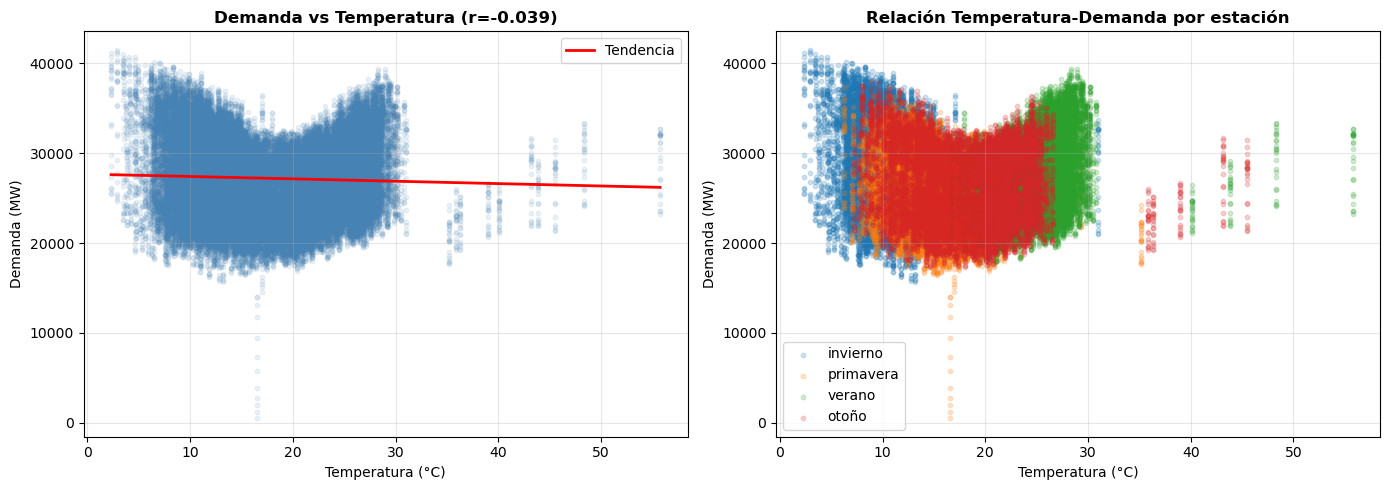

✅ Gráfico guardado: 04_correlacion_temperatura.png


In [31]:
# =============================================================
# 4.4 CORRELACIÓN CON TEMPERATURA
# =============================================================
print("\n4.4 CORRELACIÓN CON TEMPERATURA")
print("-" * 70)

correlacion_temp = df["demanda_mw"].corr(df["temperatura_c"])
print(f"Correlación Demanda-Temperatura: {correlacion_temp:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(df["temperatura_c"], df["demanda_mw"], alpha=0.1, s=10, color="steelblue")
# Línea de tendencia
z = np.polyfit(df["temperatura_c"], df["demanda_mw"], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df["temperatura_c"].unique()), 
             p(sorted(df["temperatura_c"].unique())), 
             "r-", linewidth=2, label="Tendencia")
axes[0].set_xlabel("Temperatura (°C)")
axes[0].set_ylabel("Demanda (MW)")
axes[0].set_title(f"Demanda vs Temperatura (r={correlacion_temp:.3f})", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Por estación
for estacion in ["invierno", "primavera", "verano", "otoño"]:
    df_estacion = df[df["estacion"] == estacion]
    axes[1].scatter(df_estacion["temperatura_c"], df_estacion["demanda_mw"], 
                    alpha=0.2, s=10, label=estacion)
axes[1].set_xlabel("Temperatura (°C)")
axes[1].set_ylabel("Demanda (MW)")
axes[1].set_title("Relación Temperatura-Demanda por estación", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("04_correlacion_temperatura.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfico guardado: 04_correlacion_temperatura.png")


4.5 DESCOMPOSICIÓN: TENDENCIA, ESTACIONALIDAD, RESIDUO
----------------------------------------------------------------------


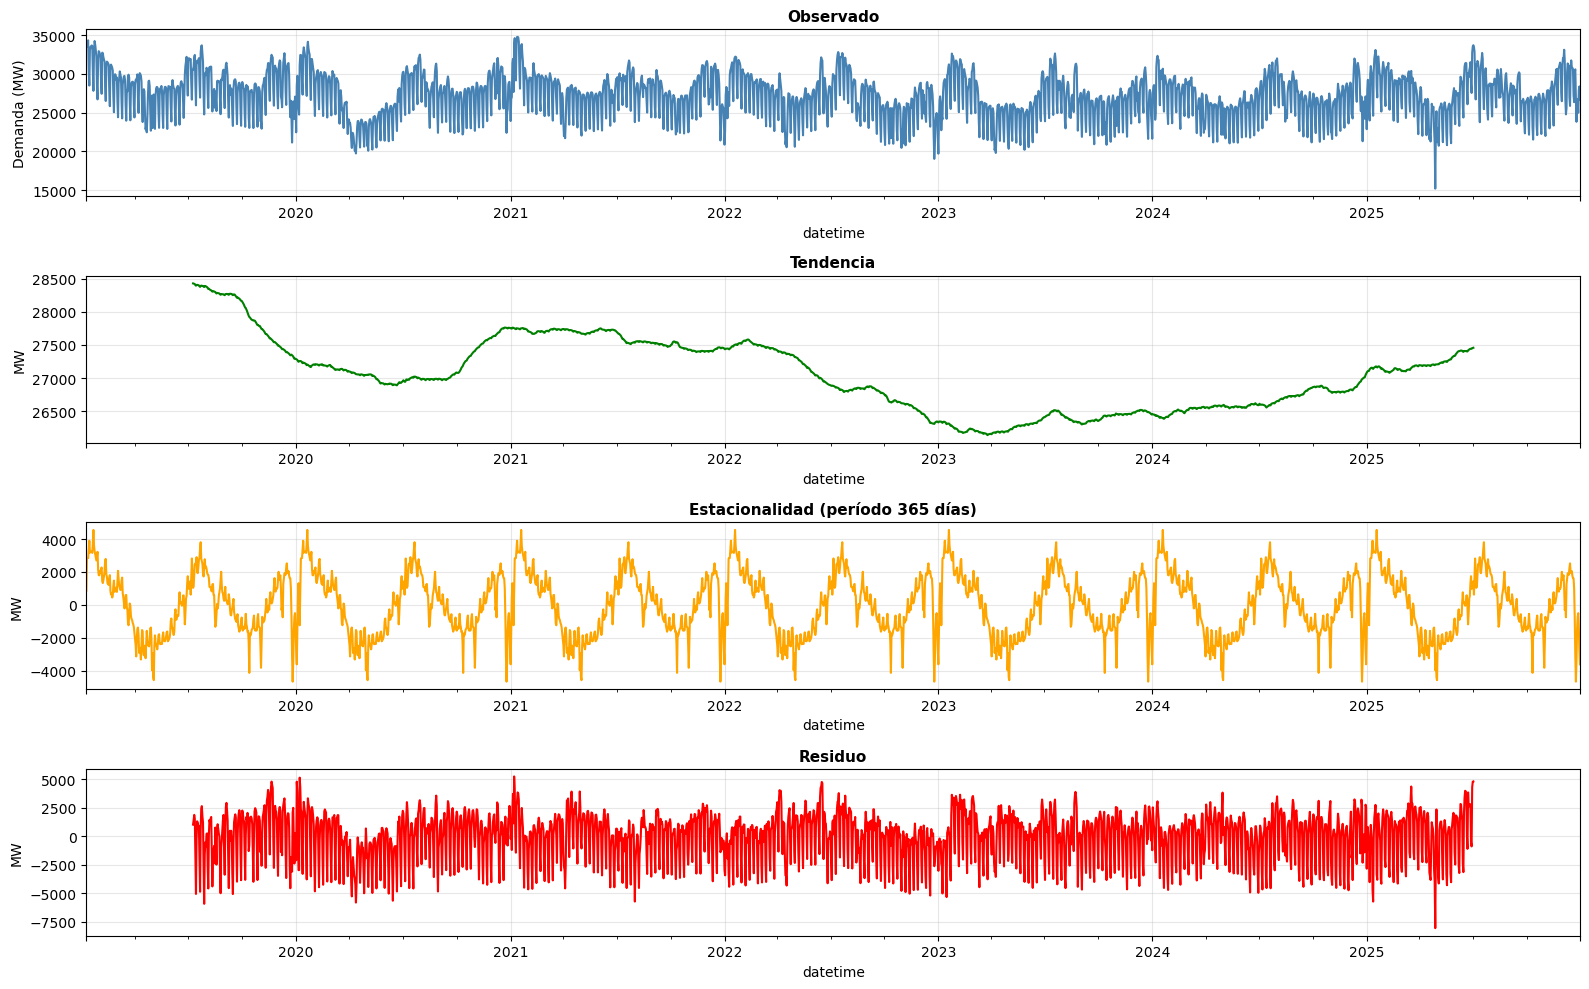

✅ Gráfico guardado: 05_descomposicion.png


In [32]:
# =============================================================
# 4.5 ESTACIONALIDAD Y TENDENCIA
# =============================================================
print("\n4.5 DESCOMPOSICIÓN: TENDENCIA, ESTACIONALIDAD, RESIDUO")
print("-" * 70)

from statsmodels.tsa.seasonal import seasonal_decompose

# Hacer resample a diario para decompose (por horas es demasiado para la gráfica)
demanda_diaria = df.set_index("datetime")["demanda_mw"].resample("D").mean()
demanda_diaria = demanda_diaria.dropna()
# Descomposición
descomposicion = seasonal_decompose(demanda_diaria, model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 10))

descomposicion.observed.plot(ax=axes[0], color="steelblue")
axes[0].set_title("Observado", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Demanda (MW)")
axes[0].grid(True, alpha=0.3)

descomposicion.trend.plot(ax=axes[1], color="green")
axes[1].set_title("Tendencia", fontsize=11, fontweight="bold")
axes[1].set_ylabel("MW")
axes[1].grid(True, alpha=0.3)

descomposicion.seasonal.plot(ax=axes[2], color="orange")
axes[2].set_title("Estacionalidad (período 365 días)", fontsize=11, fontweight="bold")
axes[2].set_ylabel("MW")
axes[2].grid(True, alpha=0.3)

descomposicion.resid.plot(ax=axes[3], color="red")
axes[3].set_title("Residuo", fontsize=11, fontweight="bold")
axes[3].set_ylabel("MW")
axes[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("05_descomposicion.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfico guardado: 05_descomposicion.png")


4.6 MATRIZ DE CORRELACIONES
----------------------------------------------------------------------


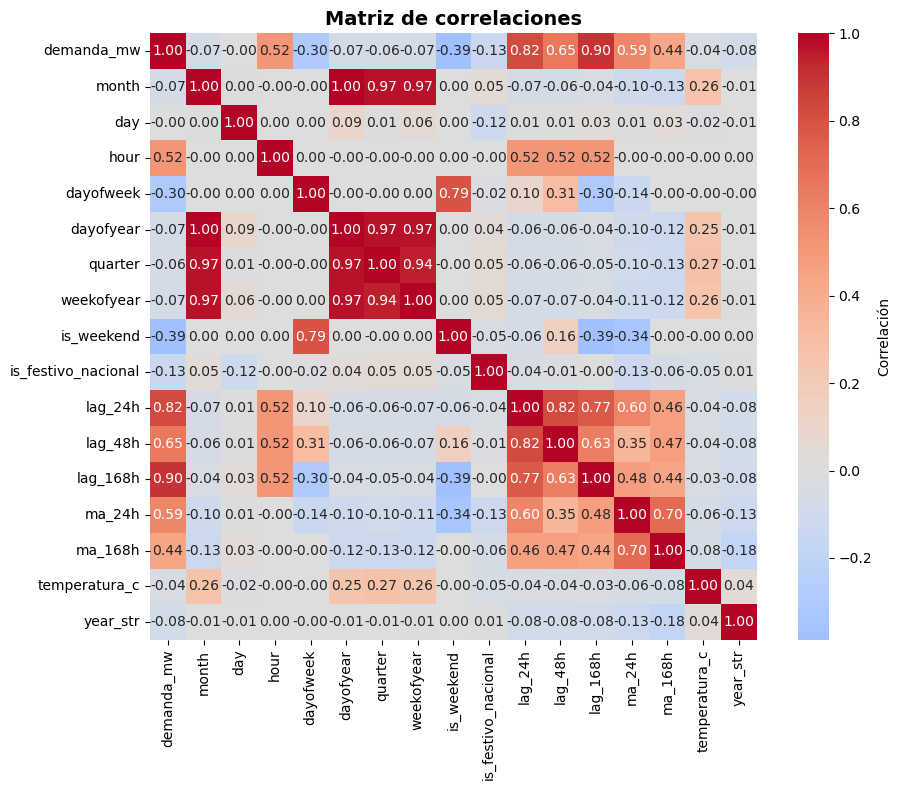

✅ Gráfico guardado: 06_matriz_correlaciones.png


In [33]:
# =============================================================
# 4.6 MATRIZ DE CORRELACIONES
# =============================================================
print("\n4.6 MATRIZ DE CORRELACIONES")
print("-" * 70)

# Seleccionar columnas numéricas
columnas_numericas = ['demanda_mw', 'month', 'day', 'hour',
       'dayofweek', 'dayofyear', 'quarter', 'weekofyear', 'is_weekend',
       'is_festivo_nacional', 'lag_24h', 'lag_48h',
       'lag_168h', 'ma_24h', 'ma_168h', 'temperatura_c', 'year_str']
df_corr = df[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, ax=ax, cbar_kws={"label": "Correlación"})
ax.set_title("Matriz de correlaciones", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("06_matriz_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfico guardado: 06_matriz_correlaciones.png")

In [34]:
# =============================================================
# 4.7 ESTADÍSTICAS DESCRIPTIVAS
# =============================================================
print("\n4.7 ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 70)

print("\nDEMANDA ELÉCTRICA (MW):")
print(df["demanda_mw"].describe())

print("\nPOR AÑO:")
print(df.groupby("year")["demanda_mw"].agg(["count", "mean", "std", "min", "max"]))

print("\nPOR MES:")
print(df.groupby("month")["demanda_mw"].agg(["mean", "std", "min", "max"]))

print("\nPOR TIPO DE DÍA:")
print(df.groupby("tipo_dia")["demanda_mw"].agg(["count", "mean", "std"]))

# Guardar en CSV para usar en el informe
df.groupby("year")["demanda_mw"].agg(["count", "mean", "std", "min", "max"]).to_csv("estadisticas_por_ano.csv")
df.groupby("month")["demanda_mw"].agg(["mean", "std", "min", "max"]).to_csv("estadisticas_por_mes.csv")

print("\n✅ Estadísticas guardadas en CSV")


4.7 ESTADÍSTICAS DESCRIPTIVAS
----------------------------------------------------------------------

DEMANDA ELÉCTRICA (MW):
count    61200.000000
mean     27202.647486
std       4388.960970
min        518.113000
25%      23633.906250
50%      27230.425000
75%      30484.188000
max      41483.001000
Name: demanda_mw, dtype: float64

POR AÑO:
      count          mean          std        min        max
year                                                        
2019   8592  28453.800632  4494.287039  17547.115  40136.265
2020   8784  26952.984756  4642.952290  16500.059  39997.189
2021   8760  27687.867610  4211.087957  17302.151  41483.001
2022   8760  26883.672832  4317.088277  15722.743  38048.702
2023   8760  26412.900404  4245.139071  16272.179  38758.431
2024   8784  26597.017580  4032.659027  17437.935  38198.780
2025   8760  27456.626573  4412.806131    518.113  39956.705

POR MES:
               mean          std        min        max
month                                   


4.8 ANÁLISIS DEL IMPACTO COVID-19
----------------------------------------------------------------------
Demanda promedio marzo-mayo 2019: 27249.70 MW
Demanda promedio marzo-mayo 2020: 24167.29 MW
Diferencia: -11.31%


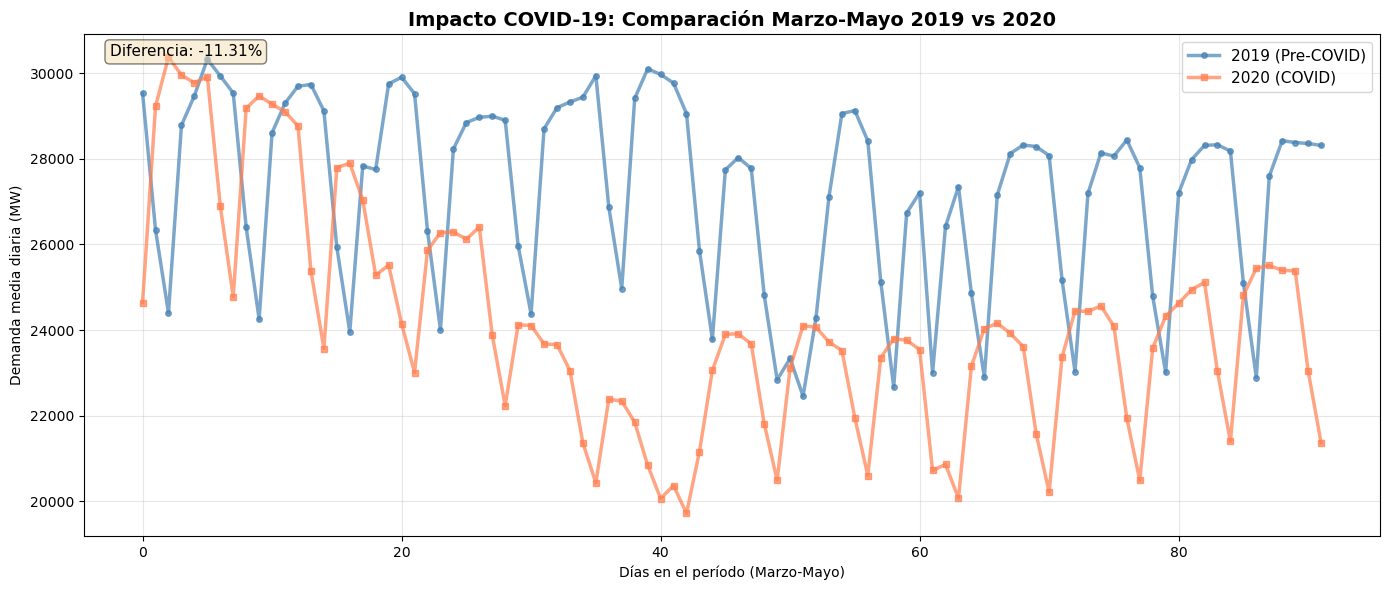

✅ Gráfico guardado: 07_impacto_covid.png


In [35]:
# =============================================================
# 4.8 IMPACTO DEL COVID (ANÁLISIS ESPECIAL)
# =============================================================
print("\n4.8 ANÁLISIS DEL IMPACTO COVID-19")
print("-" * 70)

df_covid = df[(df["year"] == 2020) & (df["month"].isin([3, 4, 5]))].copy()
df_pre_covid = df[(df["year"] == 2019) & (df["month"].isin([3, 4, 5]))].copy()

demanda_covid = df_covid["demanda_mw"].mean()
demanda_pre_covid = df_pre_covid["demanda_mw"].mean()
diferencia = ((demanda_covid - demanda_pre_covid) / demanda_pre_covid) * 100

print(f"Demanda promedio marzo-mayo 2019: {demanda_pre_covid:.2f} MW")
print(f"Demanda promedio marzo-mayo 2020: {demanda_covid:.2f} MW")
print(f"Diferencia: {diferencia:.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))

# Extraer datos y resetear índice para alinear
df_2019 = df[(df["year"] == 2019) & (df["month"].isin([3, 4, 5]))].copy()
df_2020 = df[(df["year"] == 2020) & (df["month"].isin([3, 4, 5]))].copy()

# Resetear índice para alineación
demanda_2019 = df_2019.set_index("datetime")["demanda_mw"].resample("D").mean().reset_index(drop=True)
demanda_2020 = df_2020.set_index("datetime")["demanda_mw"].resample("D").mean().reset_index(drop=True)

# Plot ambos en el mismo gráfico (por número de días del período)
ax.plot(demanda_2019.values, linewidth=2.5, label="2019 (Pre-COVID)", color="steelblue", marker="o", markersize=4, alpha=0.7)
ax.plot(demanda_2020.values, linewidth=2.5, label="2020 (COVID)", color="coral", marker="s", markersize=4, alpha=0.7)

ax.set_title("Impacto COVID-19: Comparación Marzo-Mayo 2019 vs 2020", fontsize=14, fontweight="bold")
ax.set_xlabel("Días en el período (Marzo-Mayo)")
ax.set_ylabel("Demanda media diaria (MW)")
ax.legend(fontsize=11, loc="best")
ax.grid(True, alpha=0.3)
# Añadir estadísticas en el texto
diferencia_pct = ((demanda_2020.mean() - demanda_2019.mean()) / demanda_2019.mean()) * 100
ax.text(0.02, 0.98, f"Diferencia: {diferencia_pct:.2f}%", 
        transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig("07_impacto_covid.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfico guardado: 07_impacto_covid.png")

In [36]:
# =============================================================
# RESUMEN FINAL
# =============================================================
print("\n" + "="*70)
print("✅ EDA COMPLETADO")
print("="*70)
print("\nArchivos generados:")
print("  - 01_evolucion_historica.png")
print("  - 02_patrones_temporales.png")
print("  - 03_tipo_dia.png")
print("  - 04_correlacion_temperatura.png")
print("  - 05_descomposicion.png")
print("  - 06_matriz_correlaciones.png")
print("  - 07_impacto_covid.png")
print("  - estadisticas_por_ano.csv")
print("  - estadisticas_por_mes.csv")


✅ EDA COMPLETADO

Archivos generados:
  - 01_evolucion_historica.png
  - 02_patrones_temporales.png
  - 03_tipo_dia.png
  - 04_correlacion_temperatura.png
  - 05_descomposicion.png
  - 06_matriz_correlaciones.png
  - 07_impacto_covid.png
  - estadisticas_por_ano.csv
  - estadisticas_por_mes.csv


In [37]:
# =============================================================
# 5. MODELADO PREDICTIVO
# =============================================================

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

print("\n" + "="*70)
print("5. MODELADO PREDICTIVO")
print("="*70)

df = df.sort_values("datetime").reset_index(drop=True)

FECHA_CORTE = "2025-01-01"  # todo lo anterior = train, resto = test


def evaluar(y_true, y_pred, nombre_modelo):
    """Calcula MAE, RMSE y MAPE y los devuelve en un dict."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n📊 {nombre_modelo}")
    print(f"   MAE:  {mae:,.2f} MW")
    print(f"   RMSE: {rmse:,.2f} MW")
    print(f"   MAPE: {mape:.2f}%")
    return {"modelo": nombre_modelo, "MAE": mae, "RMSE": rmse, "MAPE": mape}


resultados = []


5. MODELADO PREDICTIVO


In [38]:
# =============================================================
# 5.1 SPLIT TEMPORAL
# =============================================================
print("\n5.1 SPLIT TEMPORAL")
print("-" * 70)

train = df[df["datetime"] < FECHA_CORTE].copy()
test = df[df["datetime"] >= FECHA_CORTE].copy()
print(f"Train: {train.shape} ({train['datetime'].min()} → {train['datetime'].max()})")
print(f"Test:  {test.shape} ({test['datetime'].min()} → {test['datetime'].max()})")


5.1 SPLIT TEMPORAL
----------------------------------------------------------------------
Train: (52440, 29) (2019-01-08 00:00:00+01:00 → 2024-12-31 23:00:00+01:00)
Test:  (8760, 29) (2025-01-01 00:00:00+01:00 → 2025-12-31 23:00:00+01:00)


In [39]:
# =============================================================
# 5.2 SARIMAX 
# =============================================================
print("\n5.2 SARIMAX")
print("-" * 70)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

demanda_diaria_mod = df.set_index("datetime")["demanda_mw"].resample("D").mean()
temp_diaria_mod = df.set_index("datetime")["temperatura_c"].resample("D").mean()
demanda_diaria_mod = demanda_diaria_mod.dropna()
temp_diaria_mod = temp_diaria_mod.reindex(demanda_diaria_mod.index).interpolate(limit_direction="both")
adf_result = adfuller(demanda_diaria_mod.dropna())
print(f"ADF statistic: {adf_result[0]:.4f} | p-value: {adf_result[1]:.4f}")
print("  -> Serie estacionaria" if adf_result[1] < 0.05 else "  -> Serie NO estacionaria")


5.2 SARIMAX
----------------------------------------------------------------------
ADF statistic: -5.4003 | p-value: 0.0000
  -> Serie estacionaria


In [40]:
train_diario = demanda_diaria_mod[demanda_diaria_mod.index < FECHA_CORTE]
test_diario = demanda_diaria_mod[demanda_diaria_mod.index >= FECHA_CORTE]
exog_train = temp_diaria_mod[temp_diaria_mod.index < FECHA_CORTE].values.reshape(-1, 1)
exog_test = temp_diaria_mod[temp_diaria_mod.index >= FECHA_CORTE].values.reshape(-1, 1)

try:
    import pmdarima as pm
    auto_model = pm.auto_arima(
        train_diario, exogenous=exog_train,
        seasonal=True, m=7, trace=True,
        error_action="ignore", suppress_warnings=True, stepwise=True
    )
    order, seasonal_order = auto_model.order, auto_model.seasonal_order
    print(f"Orden óptimo (auto_arima): {order} x {seasonal_order}")
except ImportError:
    print("pmdarima no instalado, usando orden manual (1,1,1)(1,1,1,7)")
    order, seasonal_order = (1, 1, 1), (1, 1, 1, 7)

modelo_sarimax = SARIMAX(
    train_diario, exog=exog_train, order=order, seasonal_order=seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
print(modelo_sarimax.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=5.81 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=39795.067, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=37375.690, Time=1.15 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=38568.337, Time=1.17 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=39793.072, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=39790.603, Time=0.15 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=37091.944, Time=2.31 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=3.67 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=1.89 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=37091.252, Time=2.36 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=37375.467, Time=0.59 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=3.15 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=2.46 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=37091.073, Time=3.19 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=37374.4


📊 SARIMAX (rolling 1 día)
   MAE:  839.34 MW
   RMSE: 1,318.81 MW
   MAPE: 3.16%


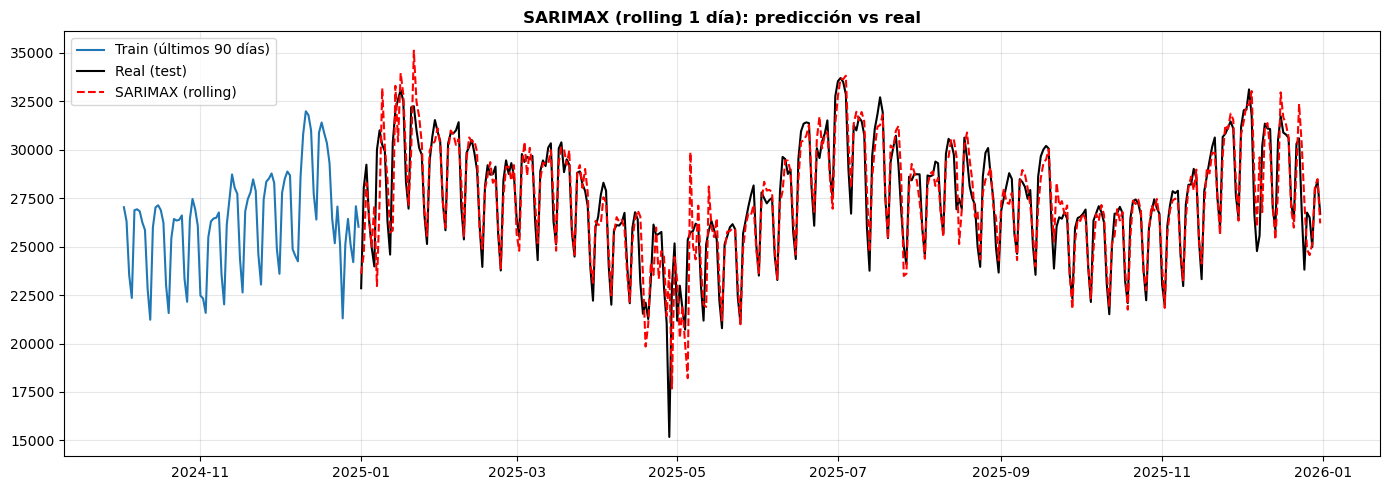

✅ Gráfico guardado: 08_sarimax_prediccion.png


In [41]:
predicciones_rolling = []
modelo_actual = modelo_sarimax

for i in range(len(test_diario)):
    pred_paso = modelo_actual.forecast(steps=1, exog=exog_test[i:i+1])
    predicciones_rolling.append(pred_paso.values[0])
    modelo_actual = modelo_actual.append(
        endog=[test_diario.values[i]],
        exog=exog_test[i:i+1], refit=False)

y_pred_sarimax = pd.Series(predicciones_rolling, index=test_diario.index)
resultados.append(evaluar(test_diario.values, y_pred_sarimax.values, "SARIMAX (rolling 1 día)"))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_diario.index[-90:], train_diario.values[-90:], label="Train (últimos 90 días)")
ax.plot(test_diario.index, test_diario.values, label="Real (test)", color="black")
ax.plot(test_diario.index, y_pred_sarimax.values, label="SARIMAX (rolling)", color="red", linestyle="--")
ax.set_title("SARIMAX (rolling 1 día): predicción vs real", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("08_sarimax_prediccion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado: 08_sarimax_prediccion.png")

In [42]:
# =============================================================
# 5.3 XGBOOST (a nivel horario, con todas las features)
# =============================================================
print("\n5.3 XGBOOST")
print("-" * 70)

from xgboost import XGBRegressor

FEATURES = [
    "hour", "dayofweek", "month", "is_weekend", "is_festivo_nacional",
    "lag_24h", "lag_48h", "lag_168h", "ma_24h", "ma_168h",
    "hour_sin", "hour_cos", "dayofweek_sin", "dayofweek_cos",
    "month_sin", "month_cos", "temperatura_c"
]

X_train, y_train = train[FEATURES], train["demanda_mw"]
X_test, y_test = test[FEATURES], test["demanda_mw"]

tscv = TimeSeriesSplit(n_splits=3)

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    {"n_estimators": [300, 500], "max_depth": [4, 6], "learning_rate": [0.05, 0.1]},
    cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid_xgb.fit(X_train, y_train)
modelo_xgb = grid_xgb.best_estimator_
print(f"Mejores hiperparámetros XGBoost: {grid_xgb.best_params_}")


5.3 XGBOOST
----------------------------------------------------------------------
Mejores hiperparámetros XGBoost: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}



📊 XGBoost
   MAE:  601.92 MW
   RMSE: 1,083.67 MW
   MAPE: 3.28%


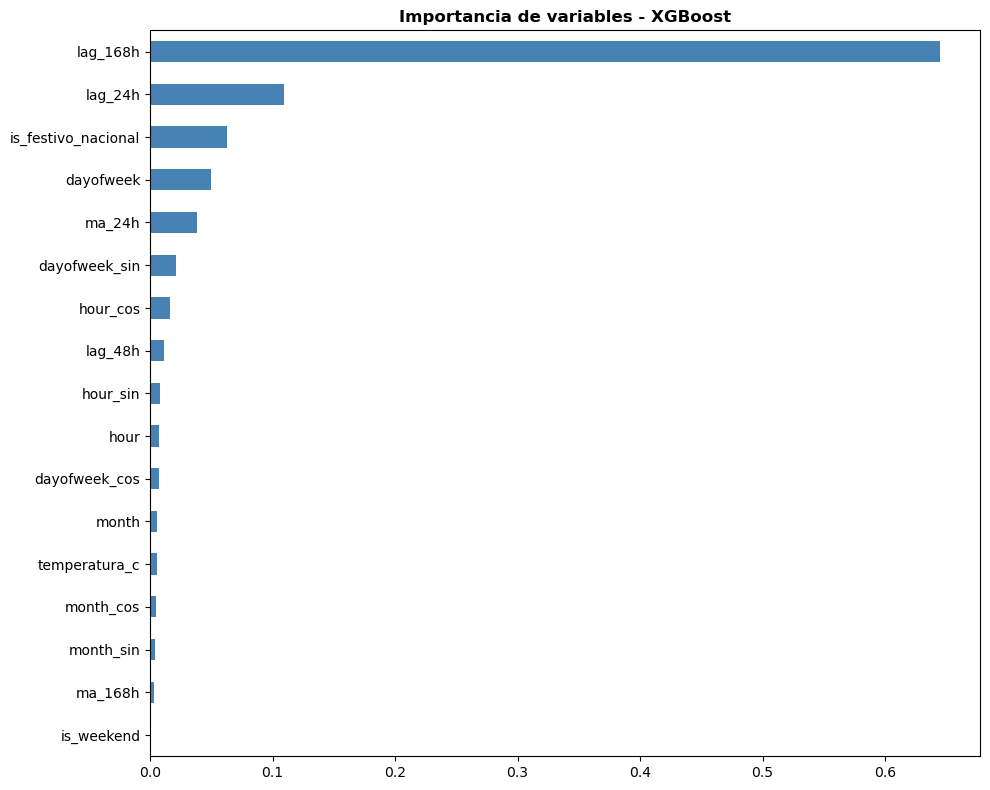

✅ Gráfico guardado: 09_xgboost_importancia.png


In [43]:
y_pred_xgb = modelo_xgb.predict(X_test)
resultados.append(evaluar(y_test.values, y_pred_xgb, "XGBoost"))

importancias = pd.Series(modelo_xgb.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
importancias.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Importancia de variables - XGBoost", fontweight="bold")
plt.tight_layout()
plt.savefig("09_xgboost_importancia.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado: 09_xgboost_importancia.png")

In [44]:
# =============================================================
# 5.4 LIGHTGBM
# =============================================================
print("\n5.4 LIGHTGBM")
print("-" * 70)

from lightgbm import LGBMRegressor

grid_lgbm = GridSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    {"n_estimators": [300, 500], "max_depth": [5, 8], "learning_rate": [0.05, 0.1]},
    cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid_lgbm.fit(X_train, y_train)
modelo_lgbm = grid_lgbm.best_estimator_
print(f"Mejores hiperparámetros LightGBM: {grid_lgbm.best_params_}")


5.4 LIGHTGBM
----------------------------------------------------------------------
Mejores hiperparámetros LightGBM: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 500}


In [45]:
y_pred_lgbm = modelo_lgbm.predict(X_test)
resultados.append(evaluar(y_test.values, y_pred_lgbm, "LightGBM"))


📊 LightGBM
   MAE:  596.87 MW
   RMSE: 1,059.55 MW
   MAPE: 3.23%



5.6 SHAP
----------------------------------------------------------------------


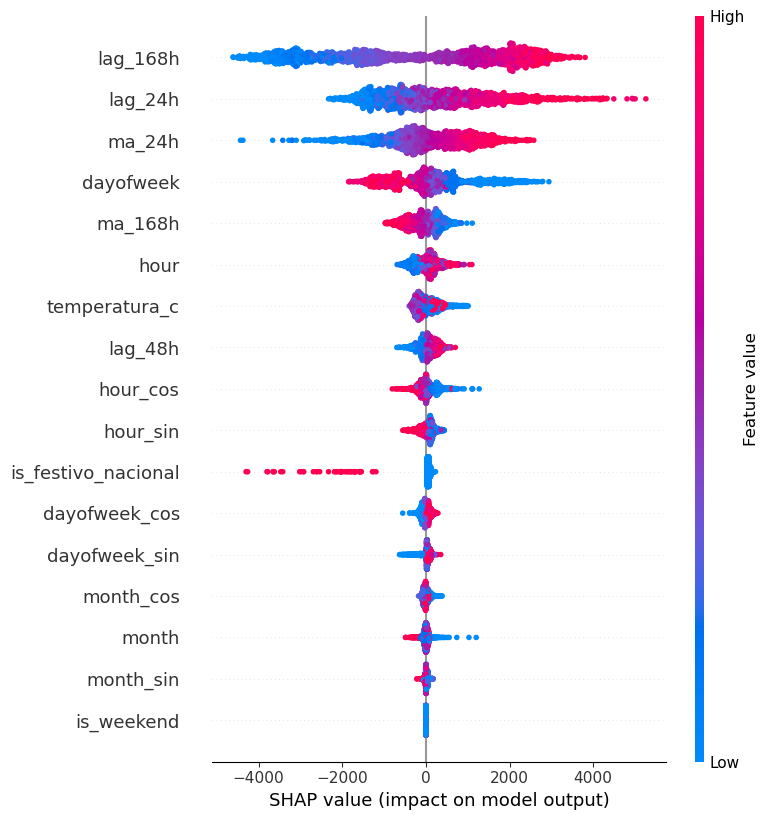

✅ Gráfico guardado: 11_shap_summary.png


In [46]:
# =============================================================
# 5.5 SHAP
# =============================================================
print("\n5.6 SHAP")
print("-" * 70)

import shap

explainer = shap.TreeExplainer(modelo_xgb)
muestra = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(muestra)
shap.summary_plot(shap_values, muestra, show=False)
plt.tight_layout()
plt.savefig("10_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado: 11_shap_summary.png")

In [47]:
# =============================================================
# 5.7 COMPARATIVA FINAL DE MODELOS
# =============================================================
print("\n5.7 COMPARATIVA FINAL")
print("-" * 70)

df_resultados = pd.DataFrame(resultados).sort_values("MAPE")
print(df_resultados.to_string(index=False))
df_resultados.to_csv("comparativa_modelos.csv", index=False)


5.7 COMPARATIVA FINAL
----------------------------------------------------------------------
                 modelo        MAE        RMSE     MAPE
SARIMAX (rolling 1 día) 839.344452 1318.811401 3.160594
               LightGBM 596.873270 1059.552109 3.233473
                XGBoost 601.923618 1083.674311 3.275652


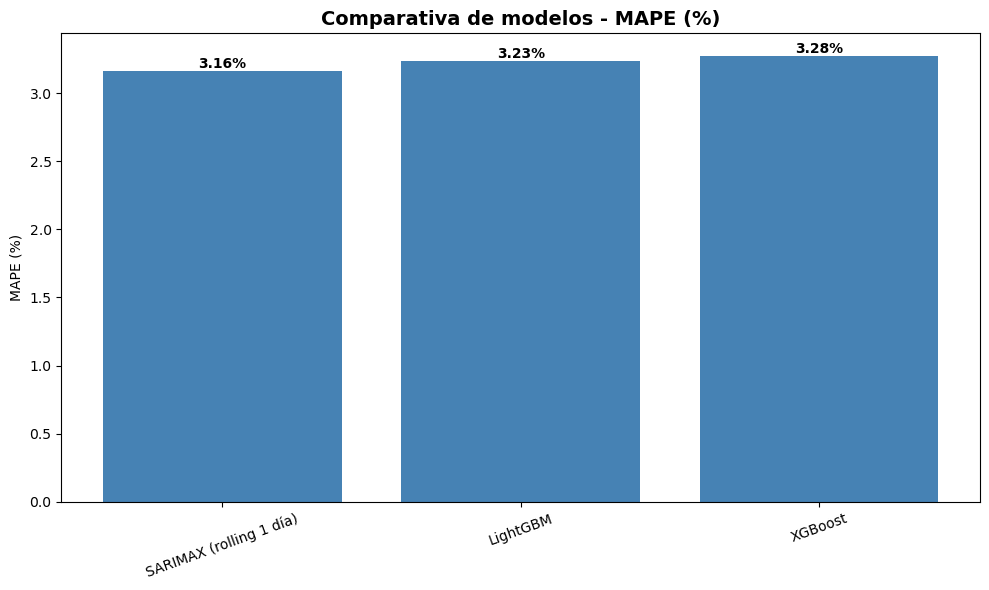

✅ Gráfico guardado: 12_comparativa_modelos.png


In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_resultados["modelo"], df_resultados["MAPE"], color="steelblue")
ax.set_title("Comparativa de modelos - MAPE (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("MAPE (%)")
for i, v in enumerate(df_resultados["MAPE"]):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("11_comparativa_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado: 12_comparativa_modelos.png")

In [49]:
# =============================================================
# RESUMEN FINAL DEL MODELADO
# =============================================================
print("\n" + "="*70)
print("✅ MODELADO COMPLETADO")
print("="*70)
print("\nArchivos generados:")
print("  - 08_sarimax_prediccion.png")
print("  - 09_xgboost_importancia.png")
print("  - 10_shap_summary.png")
print("  - 11_comparativa_modelos.png")
print("  - comparativa_modelos.csv")


✅ MODELADO COMPLETADO

Archivos generados:
  - 08_sarimax_prediccion.png
  - 09_xgboost_importancia.png
  - 10_shap_summary.png
  - 11_comparativa_modelos.png
  - comparativa_modelos.csv


In [50]:
# =============================================================
# 5.8 GUARDAR MODELOS Y PREDICCIONES
# =============================================================
print("\n5.8 GUARDANDO MODELOS Y PREDICCIONES")
print("-" * 70)

import joblib

# --- Modelos entrenados ---
joblib.dump(modelo_xgb, "modelo_xgb.pkl")
joblib.dump(modelo_lgbm, "modelo_lgbm.pkl")
print("✅ Modelos guardados: modelo_xgb.pkl, modelo_lgbm.pkl")


5.8 GUARDANDO MODELOS Y PREDICCIONES
----------------------------------------------------------------------
✅ Modelos guardados: modelo_xgb.pkl, modelo_lgbm.pkl


In [51]:
print("\n5.8 GUARDANDO MODELOS Y PREDICCIONES (versión app)")
print("-" * 70)

import joblib
import json

joblib.dump(modelo_xgb, "modelo_xgb.pkl")
joblib.dump(modelo_lgbm, "modelo_lgbm.pkl")
print("✅ Modelos guardados: modelo_xgb.pkl, modelo_lgbm.pkl")

# --- Predicciones horarias CON todas las features (para simulador y SHAP) ---
predicciones_horarias = pd.concat(
    [
        test[["datetime", "demanda_mw", "tipo_dia"]].reset_index(drop=True),
        X_test.reset_index(drop=True),  # todas las FEATURES, incl. temperatura_c
    ],
    axis=1,
)
predicciones_horarias["pred_xgboost"] = y_pred_xgb
predicciones_horarias["pred_lightgbm"] = y_pred_lgbm
predicciones_horarias.to_csv("predicciones_horarias.csv", index=False)
print(f"✅ Predicciones horarias (con features completas) guardadas: {predicciones_horarias.shape}")


5.8 GUARDANDO MODELOS Y PREDICCIONES (versión app)
----------------------------------------------------------------------
✅ Modelos guardados: modelo_xgb.pkl, modelo_lgbm.pkl
✅ Predicciones horarias (con features completas) guardadas: (8760, 22)


In [52]:
# --- Predicciones diarias (SARIMAX) ---
predicciones_diarias = pd.DataFrame({
    "fecha": test_diario.index,
    "demanda_real": test_diario.values,
    "pred_sarimax": y_pred_sarimax.values})
predicciones_diarias.to_csv("predicciones_diarias.csv", index=False)
print(f"✅ Predicciones diarias guardadas: {predicciones_diarias.shape}")

✅ Predicciones diarias guardadas: (365, 3)


In [53]:
# --- Importancia de variables ---
importancias.reset_index().rename(
    columns={"index": "variable", 0: "importancia"}
).to_csv("importancia_variables.csv", index=False)
print("✅ Importancia de variables guardada")

✅ Importancia de variables guardada


In [54]:
# --- FEATURES (orden exacto que espera el modelo) ---
with open("features_modelo.json", "w") as f:
    json.dump(FEATURES, f)

print("\nTodo listo para la app ampliada.")


Todo listo para la app ampliada.


In [55]:
resultado_naive = evaluar(test["demanda_mw"].values, test["lag_24h"].values, "Naive (persistencia 24h)")
resultados.append(resultado_naive)


📊 Naive (persistencia 24h)
   MAE:  1,819.94 MW
   RMSE: 2,817.67 MW
   MAPE: 7.62%
